# Redes neuronales recurrentes

Las Redes Neuronales Recurrentes (RNN de sus siglas en ingles) se caracterizan por dividir su input como una serie de puntos de datos (ordenados). Esta serie de datos las va recibiendo de forma progresiva almacenando informacion de **estado** entre distintas iteraciones de una misma serie.

Cada vez que una RNN recibe un input combina lo recibido con la informacion de estado y eso es lo que se usa como input. El output producido se usa como estado del siguiente paso.

En el primer paso no hay estado por lo que se remplaza con un vector de zeros.

A continuacion se muestra un pseudocodigo que representa el funcionamiento de una RNN.

In [ ]:
state_t = 0 # <- El estado empieza en 0
for input_t in input_sequence:  # <- Iterar sobre los elementos de la sequencia
    output_t = f(input_t, state_t)
    state_t = output_t  # <- El otput se usa como estado de la proxima iteracion

La funcion `f()` que transforma la tupla `(input_t, state_t)` en un *output* puede desarrollar de forma similar a como se hace con una red *feedfoward* densamente conectada. Con una matriz de pesos W para multiplicar el *input* y un vector de sesgos *b* para sumar. Pero se agrega una matriz **U que multiplica el estado**. 

In [ ]:
state_t = 0
for input_t in input_sequence:
    output_t = activation(dot(W, input_t) + dot(U, state_t) + b)
    state_t = output_t

A continuacion se desarrolla este concepto hasta una implementacion Numpy del paso hacia adelante de una RNN.

In [ ]:
import numpy as np

timesteps = 100 # <- Numero de pasos en la secuencia de entrada
input_features = 32 # <- Dimencion de espacio de entrada
output_features = 64 # <- Dimencion de espacio de salida

inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features))

W = np.random.random((output_features, input_features))
U = np.random.random((output_features, input_features))
b = np.random.random((output_features, ))

successive_outputs = []
for input_t in inputs:
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t

final_output_sequence = np.concatenate(successive_outputs, axis=0)
# La salida final es un vector 2D de tamaño (timesteps, output_features)

Una RNN es similar a un bucle `for` donde cada iteracion usa informacion que produjo la iteracion anterior. 

Hay secuencialidad en como se requiere la salida de una iteracion anterior en cada paso, esto **limita el paralelismo** de operaciones al procesar una serie (aun se pueden procesar varias series juntas). 

En el panorama de vision por computadora RNN era uno de los principales contendientes en su momento pero la aparicion de modelos totalmente paralelisables como YOLO desplazaron el uso de este tipo de redes para este tipo de problemas.

![image.png](images/6.2.rnn-execution.png)

# RNN en Keras

Keras implementa su propio modelo de capa `SimpleRNN`, a diferencia del metodo construido este no procesa las secuencias de forma individual sino que procesa las salidas de a lotes. Hay que considerar una dimension extra en el vector de entrada *(batch_size, timesteps, input_features)*.

La salida puede ser el tensor de salidas entero *(batch_size, timesteps, output_features)* o tan solo el ultimo output de cada secuencia *(batch_size, output_features)*. El comportamiento se regula con el parametro `return_sequences`.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN

model = Sequential()
model.add(Embedding(10000, 32, input_shape=(10,))) # Input shape provicional (para summary)
model.add(SimpleRNN(32, return_sequences=False))
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 1, 32)          │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,080 (1.23 MB)

 Trainable params: 322,080 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN

model = Sequential()
model.add(Embedding(10000, 32, input_shape=(10,))) # Input shape provicional (para summary)
model.add(SimpleRNN(32, return_sequences=True))
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 10, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, 10, 32)         │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,080 (1.23 MB)

 Trainable params: 322,080 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

La primera version solo informa como salida el ultimo *output* de (32,), la segunda informa un arreglo acorde a la cantidad de palabras procesadas. 

En el segundo se convienrten 10 palabras por input en embedding. Los 10 embeddings son recibidos de forma progresiva por la RNN produciendo 10 *outputs*, ese es el output de la red.

En pos de incrementar el poder de representacion a veces se apilan varias RNN *layers*.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN

model = Sequential()
model.add(Embedding(10000, 32, input_shape=(10,))) # Input shape provicional (para summary)
model.add(SimpleRNN(32, return_sequences=True))
model.add(SimpleRNN(32, return_sequences=True))
model.add(SimpleRNN(32, return_sequences=True))
model.add(SimpleRNN(32))
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 10, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ (None, 10, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_12 (SimpleRNN)       │ (None, 10, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ (None, 10, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_14 (SimpleRNN)       │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,320 (1.25 MB)

 Trainable params: 328,320 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Ya que se esperan entradas *(batch, timestep, vector_size)* es necesario hacer que se informen todos los outputs de la secuencia. 

Las subsiguientes RNNs analizan no las entradas iniciales sino que el resultados del analisis que hizo la RNN previa. Osea que su entrada ya codifica informacion no solo de la palabra que le toca sino de el contexto anterior a esta, a medida que se avanza en las RNN el contexto toma mas importancia.

En la capa final solo interesa la salida final.

# RNN en IMDb

Se van a usar RNN para el problema de clasificacion de reseñas positivas o negativas del IMDd.

Preparar el conjunto de datos:

In [ ]:
from tensorflow.keras.datasets import imdb
from keras.preprocessing import sequence

max_features = 1000 # Palabras a considerar en el diccionario
max_len = 500   # Truncar en esa cantidad de palabras

print('Loading data...')
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)
print(len(input_train), 'train sequences')
print(len(input_test), 'test sequences') 

print('Pad sequences (samples x time)')
input_train = sequence.pad_sequences(input_train, maxlen=max_len)
input_test = sequence.pad_sequences(input_test, maxlen=max_len)
print('input_train shape', input_train.shape)
print('input_test shape', input_test.shape)

Loading data...
25000 train sequences
25000 test sequences
Pad sequences (samples x time)
input_train shape (25000, 500)
input_test shape (25000, 500)


Armar un modelo con una capa *Embedding* y una capa *SimpleRNN*.

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN

model = Sequential()
model.add(Embedding(max_features, 32, input_shape=(10,))) # Input shape provicional
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(input_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10


2025-09-10 22:35:50.764233: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 40000000 exceeds 10% of free system memory.
I0000 00:00:1757554551.752645  311058 service.cc:152] XLA service 0x55ee5b2d3e90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757554551.752662  311058 service.cc:160]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2025-09-10 22:35:51.889404: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1757554552.154462  311058 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1757554555.527244  311058 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 164ms/step - acc: 0.5514 - loss: 0.6810 - val_acc: 0.7382 - val_loss: 0.5648
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - acc: 0.7519 - loss: 0.5235 - val_acc: 0.8122 - val_loss: 0.4396
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - acc: 0.7985 - loss: 0.4572 - val_acc: 0.7778 - val_loss: 0.4699
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - acc: 0.8085 - loss: 0.4250 - val_acc: 0.8098 - val_loss: 0.4292
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - acc: 0.8377 - loss: 0.3855 - val_acc: 0.8296 - val_loss: 0.3943
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - acc: 0.8419 - loss: 0.3757 - val_acc: 0.8268 - val_loss: 0.4592
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - acc: 0.8482 - loss: 0.3639 - val_acc: 0.7584 - val_loss: 0.5261
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - acc: 0.8605 - loss: 0.3345 - val_acc: 0.7974 - val_loss: 0.4418
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - ac

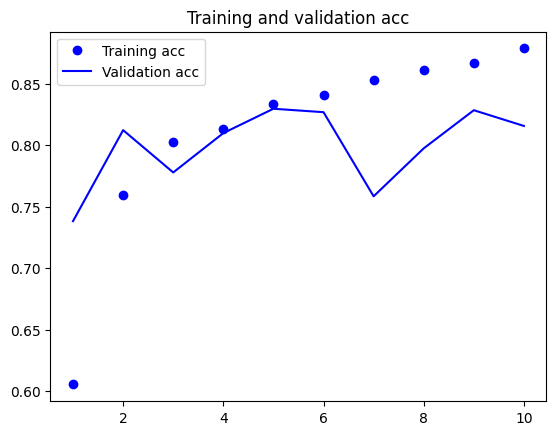

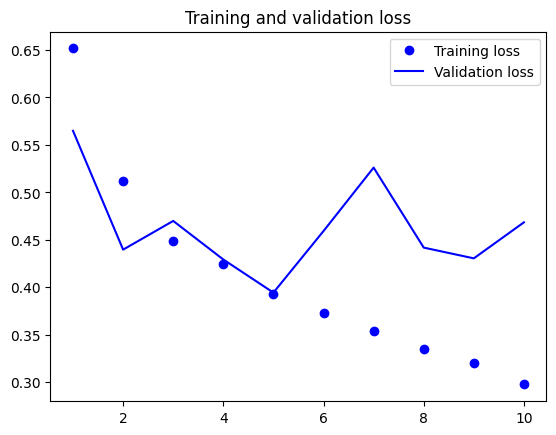

In [7]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation acc')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

Parece que *acc* en validacion se esta estancandoce y emperando a partir de la epoca 5 mientras que el *acc* en train sigue subiendo hasta el final. 

Es un caso de *overfitting*, el modelo esta aprendiendo patrones especificos de las sequencias de entrenamiento que no generalizan bien para el conjunto de validacion.

El *acc* de 84% en el mejor epoch es peor que el tope de 88% que se logro en la [seccion 3.4](/3.4.IMDb.ipynb) con un modelo Denso sencillo con tan solo 10000 reseñas para train. 

Parte del proble radica en que esta esta recibiendo menos datos (solo las primeras 500 palabras de cada reseña) pero tambien esta el problema que las RNN no son optimas para procesar secuencias largas. 

A medida que se avanza en iteraciones se diluye la informacion de iteraciones pasadas por lo que la memoria es mas bien a corto plazo.

Encadenar varias RNN ayuda con esto y hay otros tipos de capas recurrentes que pueden tener mejor rendimiento par aeste tipo de problemas.